### Data Analysis: Zomato Delivery 

### Delivery Performance Analysis: Analyze 
#### 1. delivery person ratings, 
#### 2. delivery times, and 
#### 3. identify areas for improvement

#### Data source: https://www.kaggle.com/datasets/saurabhbadole/zomato-delivery-operations-analytics-dataset

#### Description: Delve into the world of food delivery with the Zomato Delivery Dataset. This dataset provides a comprehensive view of delivery operations, including delivery person details, order timestamps, weather conditions, and more. Explore patterns, optimize delivery routes, and enhance customer satisfaction with insights from this dataset.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nltk
import seaborn as sb
from collections import Counter
import statistics
import re
from datetime import datetime

#### Data Information

In [4]:
# Import Dataset 
zomato_data = pd.read_csv("C:/Users/minjk/Downloads/Zomato Delivery Data/Zomato Dataset.csv")
zomato_data = pd.DataFrame(zomato_data)

In [7]:
zomato_data.head()
nltk.FreqDist(zomato_data.City)

FreqDist({'Metropolitian': 34087, 'Urban': 10133, nan: 1200, 'Semi-Urban': 164})

In [8]:
# Summary statistics of numerical columns of Zomato Data 
zomato_data.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [11]:
print("There are", len(zomato_data), "total entries of rows with", len(zomato_data.columns), "columns") 

There are 45584 total entries of rows with 20 columns


In [27]:
zomato_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     45584 non-null  object 
 1   rider_id                     45584 non-null  object 
 2   rider_age                    43730 non-null  float64
 3   rider_ratings                43676 non-null  float64
 4   restaurant_latitude          45584 non-null  float64
 5   restaurant_longitude         45584 non-null  float64
 6   delivery_location_latitude   45584 non-null  float64
 7   delivery_location_longitude  45584 non-null  float64
 8   order_date                   45584 non-null  object 
 9   time_orderd                  43853 non-null  object 
 10  time_picked                  45584 non-null  object 
 11  weather                      44968 non-null  object 
 12  traffic                      44983 non-null  object 
 13  vehicle_conditio

In [15]:
# Find the name of the columns 
zomato_data.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')

#### Data Wrangling 

#### 1.1 Change the name of the columns for the ease of analysis
#### 1.1 데이터 열 이름 바꾸기 

In [6]:
# Change the name of the columns for the ease of analysis 
zomato_data.columns = ['order_id', 'rider_id', 'rider_age',
       'rider_ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_location_latitude',
       'delivery_location_longitude', 'order_date', 'time_ordered',
       'time_picked', 'weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle',
       'multiple_deliveries', 'festival', 'area_type', 'delivery_min']
zomato_data.head()

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,time_picked,weather,traffic,vehicle_condition,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [8]:
# Categorical Columns of Zomato Data
zomato_cat = zomato_data[['order_id', 'rider_id',
       'rider_ratings', 'order_date', 'weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle',
       'multiple_deliveries', 'festival', 'area_type']]

#### 1.2 Create a function that plots pie-charts for selected categorical variables of the dataframe.
#### 데이터 프레임의 범주형 변수들의 파이차트 만들기 함수 
#### 범주형 변수들의 파이차트로 시각화 및 결측치 정도 확인 

In [10]:
# Create a function that automates the creation of pie-charts for selected categorical variables of the dataframe 

# Subset dataframe with selected categorical variables
zomato_cat1 = zomato_data[['weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle',
       'multiple_deliveries', 'festival', 'area_type']]

# 데이터 프레임의 범주형 변수들의 파이차트 만들기 함수 
# 범주형 변수들의 파이차트로 시각화 및 결측치 정도 확인 
def pie_chart(dataframe):
    for column in dataframe:
        pie = dataframe[column].value_counts(dropna = False) # Show the proportion of NA's for every column
        label = [entry for entry in pie.index]
        
        plt.pie(pie,labels = label, autopct = '%.1f%%')
        plt.legend(title = column.upper(), loc = "lower left", fontsize = s5.5)
        plt.show()

In [ ]:
# Notes on pie.legend parameter "loc = "  
#'upper' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

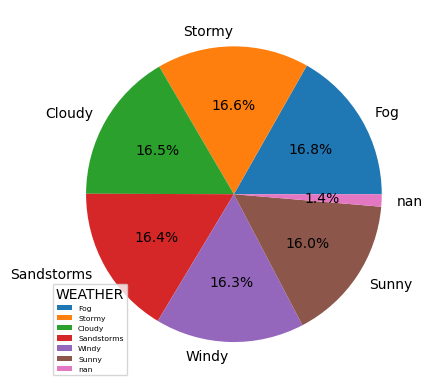

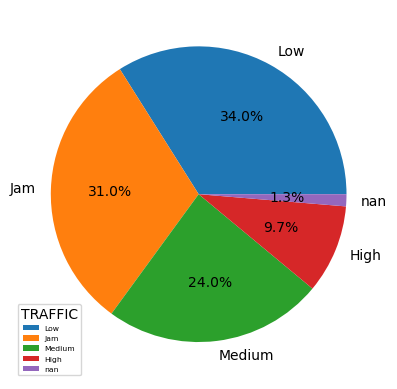

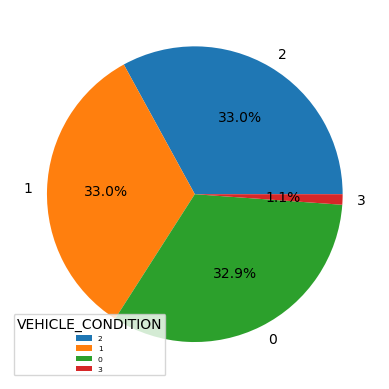

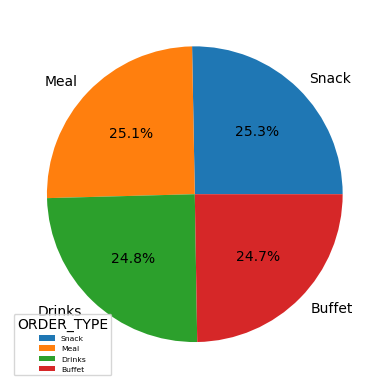

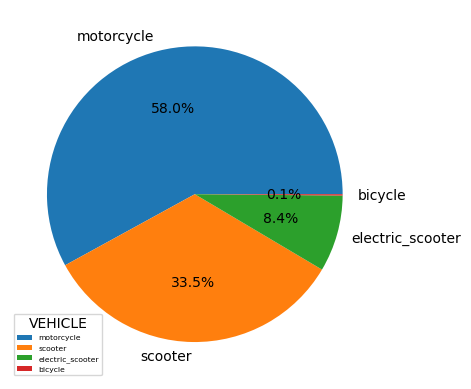

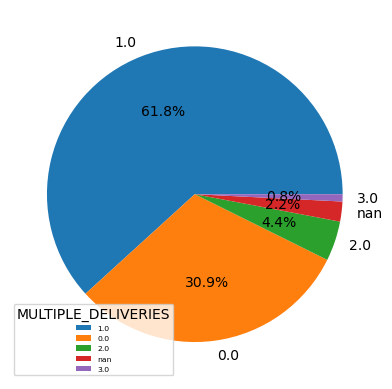

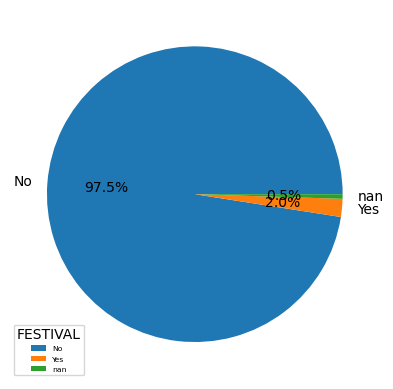

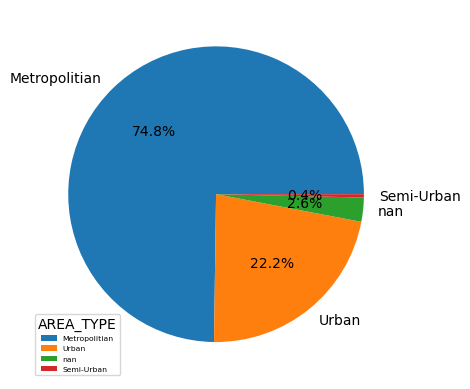

In [9]:
pie_chart(zomato_cat1)

#### Based on the pie-charts, the area_type column has the highest missing value percentage (2.6%),
#### 범주형 열 데이터 중에서는 Area Type: 지역의 종류에서 가장 많은 결측치가 확인됨 (2.6%),
#### whereas the percentages of missing values of all other categorical variables are less than or equal to 2.2%
#### 그 외에 다른 범주형 열 데이터의 결측치는 2.2% 또는 그 보다 낮은 비율의 결측치를 가지고 있음


##### 결측치 확인 예시: area_type의 결측치 행 수

In [12]:
# The area_type column has the highest percentage of NAs (2.6%) among all categorical variables.
# Diagnostics
print("Out of", len(zomato_data), "rows of data, there are", len(zomato_data[zomato_data.area_type.isna()]), "NA's for area_type column.")
zomato_data[zomato_data.area_type.isna()]

Out of 45584 rows of data, there are 1200 NA's for area_type column.


,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,time_picked,weather,traffic,vehicle_condition,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min
49,0xb002,JAPRES14DEL01,32.0,4.5,26.888420,75.800689,26.898420,75.810689,26-03-2022,09:25,09:40,Windy,Low,2,Buffet,scooter,0.0,No,NaN,20
107,0x4beb,MYSRES08DEL01,20.0,4.8,12.297954,76.665169,12.307954,76.675169,30-03-2022,09:15,09:30,Cloudy,Low,0,Drinks,motorcycle,0.0,No,NaN,16
131,0x1ec7,PUNERES05DEL03,NaN,NaN,18.543626,73.905101,18.573626,73.935101,09-03-2022,NaN,23:40,Stormy,Low,2,Snack,scooter,0.0,No,NaN,19
141,0x81a5,BANGRES04DEL03,26.0,4.4,12.980410,77.640489,13.040410,77.700489,07-03-2022,23:20,23:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,NaN,23
197,0x7bfb,COIMBRES11DEL02,20.0,4.5,11.001753,76.986241,11.021753,77.006241,03-04-2022,08:50,0.375,Fog,Low,1,Snack,motorcycle,0.0,No,NaN,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45408,0x5a9a,SURRES05DEL01,24.0,4.5,21.175104,72.804342,21.185104,72.814342,19-03-2022,08:50,09:05,Cloudy,Low,1,Drinks,motorcycle,0.0,No,NaN,16
45487,0x250b,CHENRES09DEL02,37.0,4.9,13.044694,80.261470,13.094694,80.311470,26-03-2022,1,24:15:00,Sunny,Low,2,Snack,scooter,1.0,No,NaN,12
45495,0x461,BANGRES07DEL02,NaN,NaN,-12.978453,-77.643685,12.998453,77.663685,17-03-2022,NaN,09:30,NaN,NaN,3,Meal,scooter,1.0,No,NaN,24
45541,0x7483,INDORES04DEL01,23.0,4.6,22.753659,75.903365,22.763659,75.913365,11-03-2022,08:40,08:45,Cloudy,Low,2,Snack,scooter,1.0,No,NaN,12


#### 1.3 Change order_date, time_picked, time_ordered to datetime data type 
#### 주문 날짜, 주문 시간, 주문 픽업 시간을 "datetime" 형태로 바꾸기

#### 주문 시간과 주문 픽업 시간의 년도와 날짜는 datetime으로 변환하여 분석 시에 시간 (Hour : '%H') 데이터만 추출하여 사용예정 

In [14]:
zomato_data["order_date"] = pd.to_datetime(zomato_data["order_date"], format='%d-%m-%Y')

In [16]:
zomato_data["time_picked"] = pd.to_datetime(zomato_data["time_picked"], format='%H:%M', errors = "coerce")

In [18]:
zomato_data["time_ordered"] = pd.to_datetime(zomato_data["time_ordered"], format = "%H:%M", errors = "coerce") 
# zomato_data["time_ordered"] = zomato_data["time_ordered"].strftime("%H:%M")


#### 1.4 Detect all  the Missing Values 
#### Remedial methods for missing value treatment 
#### 결측치 처리를 위해 결측치 찾기 및 제거 방법 설명

##### 1.4.1 Zomato 데이터셋의 열의 결측치 수와 비율(%) 파악하기

In [20]:
# Print the columns that contain NA's
for column in zomato_data.columns: 
    if zomato_data[column].isnull().any(axis = 0) == True:
        print(column, "contains", len(zomato_data[zomato_data[column].isna()]), "NA's :", zomato_data[column].isnull().any(axis = 0),
             round((len(zomato_data[zomato_data[column].isna()])/ len(zomato_data))*100, 2), "%")
        #print(zomato_data[zomato_data[column].isna()])

rider_age contains 1854 NA's : True 4.07 %
rider_ratings contains 1908 NA's : True 4.19 %
time_ordered contains 5799 NA's : True 12.72 %
time_picked contains 5007 NA's : True 10.98 %
weather contains 616 NA's : True 1.35 %
traffic contains 601 NA's : True 1.32 %
multiple_deliveries contains 993 NA's : True 2.18 %
festival contains 228 NA's : True 0.5 %
area_type contains 1200 NA's : True 2.63 %


#### Create a function that takes a dataframe and prints the columns that contain NA's
#### The function "print_na()" will be used to check number of Na's as we keep eliminating/imputing Na's 
#### Dataframe 형태의 데이터셋의 결측치 수와 비율을 구하는 함수


In [1]:
# Create a function that prints the columns and their proportions that contain NA's
def print_na(dataframe):
    for column in dataframe.columns: 
        if dataframe[column].isnull().any(axis = 0) == True:
            print(column, "contains", len(dataframe[dataframe[column].isna()]), "NA's:", dataframe[column].isnull().any(axis = 0),
                 round((len(dataframe[dataframe[column].isna()])/ len(dataframe))*100, 2), "%")
        #print(zomato_data[zomato_data[column].isna()])

In [24]:
print_na(zomato_data)

rider_age contains 1854 NA's: True 4.07 %
rider_ratings contains 1908 NA's: True 4.19 %
time_ordered contains 5799 NA's: True 12.72 %
time_picked contains 5007 NA's: True 10.98 %
weather contains 616 NA's: True 1.35 %
traffic contains 601 NA's: True 1.32 %
multiple_deliveries contains 993 NA's: True 2.18 %
festival contains 228 NA's: True 0.5 %
area_type contains 1200 NA's: True 2.63 %


##### 1.4.2 Visualize inspection of NA's in the dataset
##### The bright lines the location of missing values in the dataset
##### 히트맵으로 데이터셋의 결측치 시각화하기 
##### 밝은 색의 라인들이 각 행의 결측치를 나타냄 
##### 밝은 색의 라인들에 특정한 패턴이 보인다면 결측치가 random이 아니라 systematic 할 수 있음 
##### Zomato 데이터셋의 경우, 각 행에 여러개의 결측치가 있음 

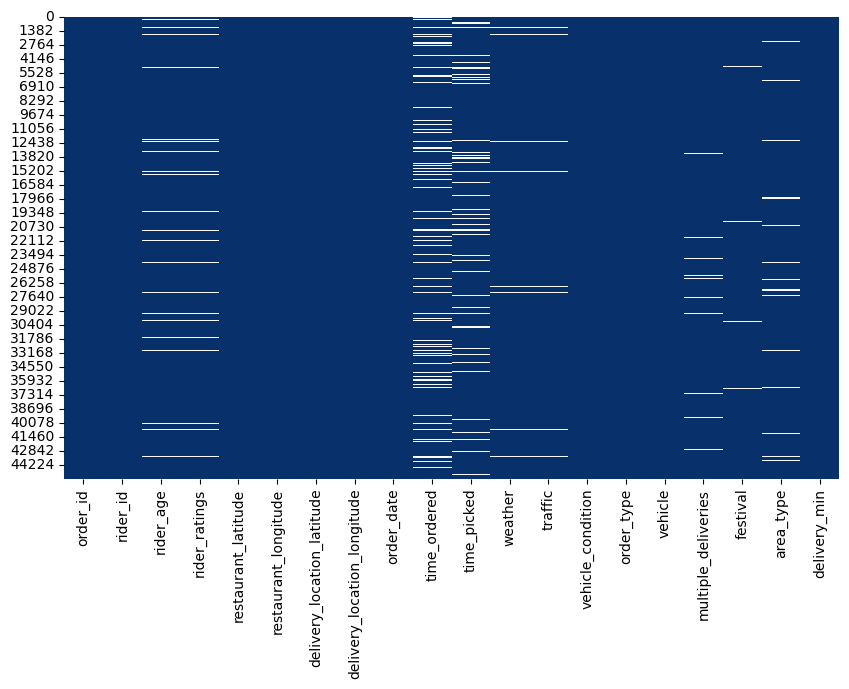

In [26]:
#### Visualize the inspection of NA's in the dataset
# In the missingness pattern plot, we can see that the bright lines are missing values
# Is missingness random, clustered, or systematic? 
plt.figure(figsize = (10, 6))

sb.heatmap(zomato_data.isna(), cmap = 'Blues_r', cbar = False);

##### 1.4.3 Find the total number of rows that has at least 1 NA in any columns 
데이터셋의 총 결측치 열의 수 찾기

In [28]:
zomato_data[zomato_data.isnull().any(axis = 1)]
round(len(zomato_data[zomato_data.isnull().any(axis = 1)])/len(zomato_data)*100, 2)

26.72

#### There are 12182 rows with at least 1 column containing NA value, which account for (26.72)% of the dataset. 
- The missingness is fairly high > 25% 
-  We found some columns like rider_age, rider_ratings, time_ordered, weather, traffic_level,\
  multiple_deliveries, area_type contain NA's
- The delivery time, which is our target (response) variable does not contain NA's


#### Conclusion on inspection of missing values:
1) High number of missing values compared to the size of the whole dataset
2) Missingness in some of the columns might be MCAR, MAR, or MNAR

#### What is our decision on missing values?
#### How do we treat missing values in this dataset? 
#### Do we remove missing values (listwise deletion) for Missing Completely at Random (MCAR)?
#### Do we impute missing values with other values, such as mean, median, or mode, for Missing at Random (MAR) or Missing Not at Random? 

#### When Missing Completely At Random (MCAR): We cannot simply remove the rows having at least 1 NA 
#### since the missingness is high > 25%.

#### When MNAR/MAR: We impute the missing values with other values.

#### For numerical variable, rider_age, rider_ratings, and time_ordered contain NA's 

##### 1.4.4. Inspect missing values in numerical variables: rider_age, rider_ratings, time_ordered

In [30]:
zomato_num_var = ['rider_age', 'rider_ratings'] 
for column in zomato_num_var: 
    if zomato_data[column].isnull().any(axis = 0) == True:
        print(column, "contains", len(zomato_data[zomato_data[column].isna()]), "NA's :", zomato_data[column].isnull().any(axis = 0))

rider_age contains 1854 NA's : True
rider_ratings contains 1908 NA's : True


##### 1.4.5. Data Entry Error in time_ordered and time_picked
##### 주문시간(time_ordered), 픽업시간 (time-picked) 이상치 감지

In [126]:
# 주문시간 (time_ordered) 이상치 감지
# 
# 주문시간이 0.833333333     449
# 0.666666667      53

# Data entry의 오류 -> 
#print(zomato_data["time_ordered"].dtype)
#nltk.FreqDist(zomato_data["time_ordered"])
#zomato_data["time_ordered"].value_counts(dropna = False)
#sorted(zomato_data["time_picked"])


##### 1.4.5. Check the distribution of delivery time conditional on missingness in a chosen variable: missing vs. non_null 
- To inspect whether the missingness of riders'age and ratings depends on delivery time or not.
1. Distribution plots of delivery time conditional on riders' age missing vs. non_null
2. Distribution plots of delivery time conditional on riders' rating missing vs. non_null

<Axes: xlabel='delivery_min', ylabel='Count'>

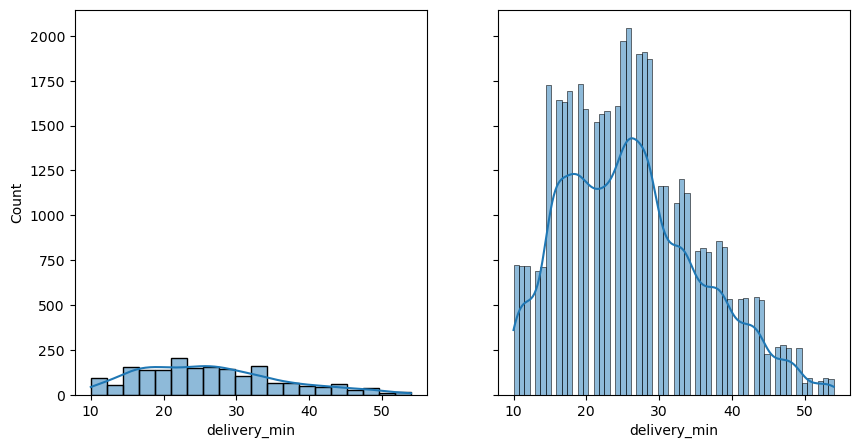

In [92]:
# Distribution plot of delivery time conditional on missing riders' age
#rider_na = zomato_data[zomato_data.rider_age.isna()]
# Plot the histograms
#plt.hist(rider_na.delivery_min)

# Distribution plot of delivery time conditional on non-missing riders' age
#rider_notNA = zomato_data[zomato_data["rider_age"].notnull()]

#plt.hist(rider_notNA.delivery_min)

fig, (ax1, ax2) =plt.subplots(ncols = 2, nrows =1 , figsize = (10,5), sharey = True) 

#sb.histplot(rider_na.delivery_min, ax = ax1, kde = True)
#sb.histplot(rider_notNA.delivery_min, ax = ax2, kde = True)

sb.histplot(zomato_data.loc[zomato_data.rider_age.isna(),"delivery_min"], ax = ax1, kde = True)
sb.histplot(zomato_data.loc[zomato_data.rider_age.notnull(), "delivery_min"] ,ax = ax2, kde = True)

<Axes: xlabel='delivery_min', ylabel='Density'>

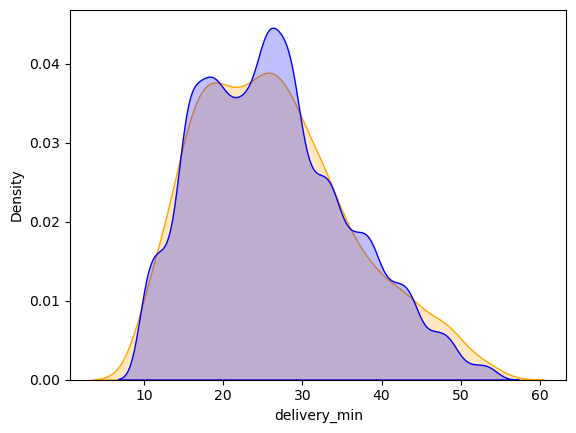

In [44]:
# kde plot
sb.kdeplot(zomato_data.loc[zomato_data.rider_age.isna(), "delivery_min"], color = "orange", fill = True)
sb.kdeplot(zomato_data.loc[zomato_data.rider_age.notnull(), "delivery_min"], color = "blue", fill = True)

<Axes: xlabel='delivery_min', ylabel='Density'>

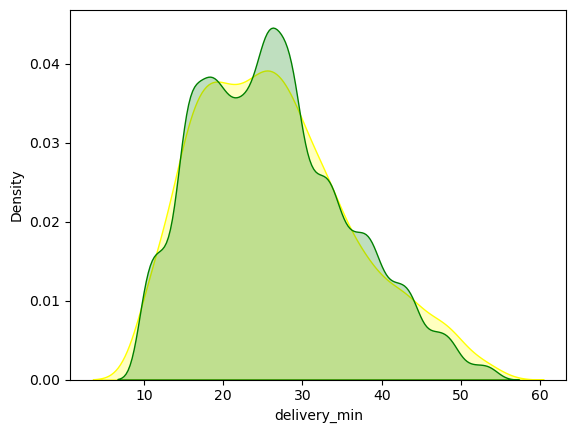

In [54]:
sb.kdeplot(zomato_data.loc[zomato_data.rider_ratings.isna(), "delivery_min"], color = "yellow", fill = True)
sb.kdeplot(zomato_data.loc[zomato_data.rider_ratings.notnull(), "delivery_min"], color = "green", fill = True)

(array([151., 288., 344., 303., 245., 223., 111., 104.,  59.,  26.]),
 array([10. , 14.4, 18.8, 23.2, 27.6, 32. , 36.4, 40.8, 45.2, 49.6, 54. ]),
 <BarContainer object of 10 artists>)

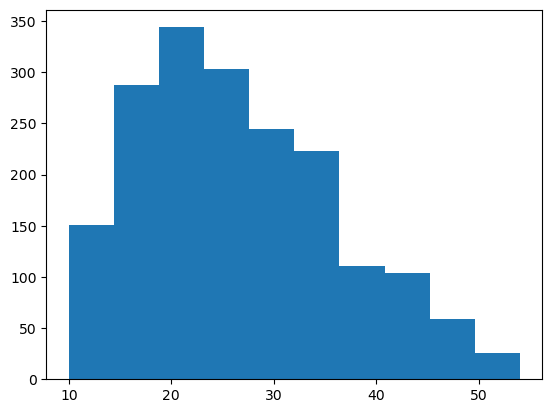

In [84]:
# Distribution plot of delivery time conditional on missing riders' age
rider_na = zomato_data[zomato_data.rider_age.isna()]
# Plot the histograms
plt.hist(rider_na.delivery_min)

(array([3557., 6689., 7989., 7523., 6106., 5013., 3005., 2371., 1067.,
         410.]),
 array([10. , 14.4, 18.8, 23.2, 27.6, 32. , 36.4, 40.8, 45.2, 49.6, 54. ]),
 <BarContainer object of 10 artists>)

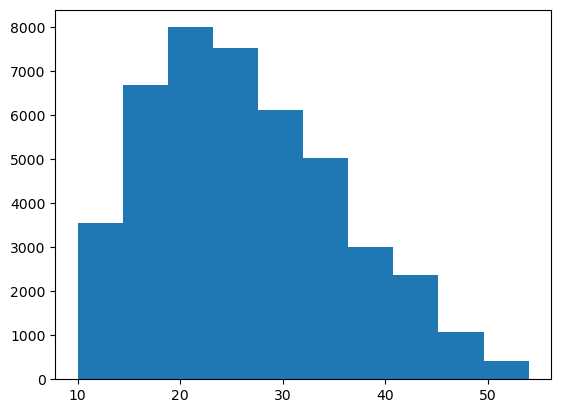

In [34]:
# Distribution plot of delivery time conditional on non-missing riders' age
rider_notNA = zomato_data[zomato_data["rider_age"].notnull()]

plt.hist(rider_notNA.delivery_min)

(array([156., 295., 357., 312., 254., 228., 114., 106.,  60.,  26.]),
 array([10. , 14.4, 18.8, 23.2, 27.6, 32. , 36.4, 40.8, 45.2, 49.6, 54. ]),
 <BarContainer object of 10 artists>)

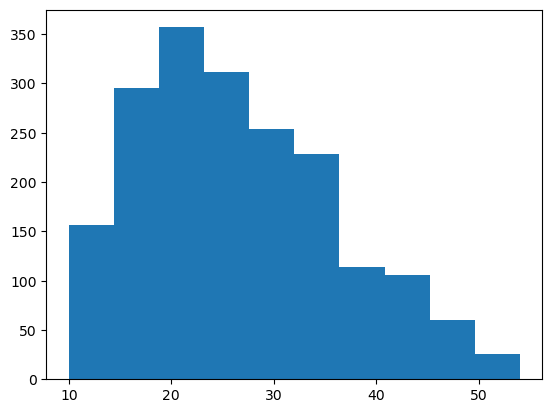

In [39]:
# Distribution plot of delivery time conditional on missing riders' ratings
ratings_na = zomato_data[zomato_data.rider_ratings.isna()]
plt.hist(ratings_na.delivery_min )

(array([3552., 6682., 7976., 7514., 6097., 5008., 3002., 2369., 1066.,
         410.]),
 array([10. , 14.4, 18.8, 23.2, 27.6, 32. , 36.4, 40.8, 45.2, 49.6, 54. ]),
 <BarContainer object of 10 artists>)

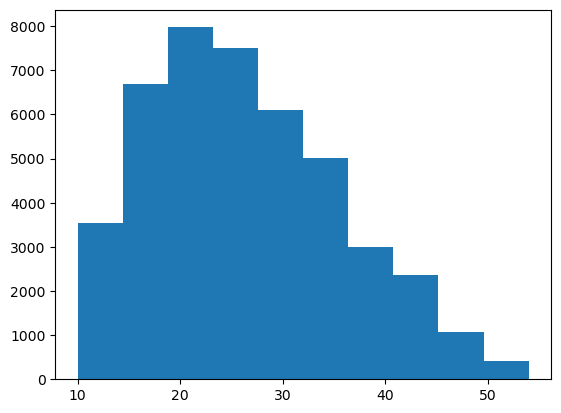

In [41]:
# Distribution plot of delivery time conditional on non-missing riders' ratings
ratings_notNA = zomato_data[zomato_data.rider_ratings.notnull()]
plt.hist(ratings_notNA.delivery_min )

##### 1.5 Decision on Missing Values: 

1. Drop the rows with rider_age and rider_ratings missing \
  since the distribution of delivery time conditional on missingness: missing vs. non_null \
  suggest that the missingness of riders' age and ratings may not depend on the delivery time.
- This implies that the missingness in riders' age and ratings may be completely at random (MCAR).
2. Moreover, since the amount of missingness for both riders age and ratings are relatively smaller \
  compared to the size of the dataset, less than 5%, we will delete the rows with missing rider age and rider ratings.

In [94]:
# Delete rows with missing rider age or rider ratings
zomato_data.dropna(subset=['rider_age', 'rider_ratings'], how='any', inplace=True)
zomato_data[zomato_data.isnull().any(axis = 1)]

# Check how many NA's are left
print_na(zomato_data)

time_ordered contains 4141 NA's: True 9.48 %
time_picked contains 4776 NA's: True 10.94 %
weather contains 91 NA's: True 0.21 %
traffic contains 91 NA's: True 0.21 %
multiple_deliveries contains 933 NA's: True 2.14 %
festival contains 217 NA's: True 0.5 %
area_type contains 1137 NA's: True 2.6 %


##### We can categorize the columns with NA's by: 

- Missingness: > 5%
1. time_ordered, time_picked

- Missingness < 5%
1. weather, traffic, multiple_deliveries, festival, area_type

##### We are going to impute the missing values for columns where missingness < 5% with mode.

In [96]:
# Impute the following missing variables with "Mode" 
# to keep the data record by imputing missing variables 

#impute_cat = zomato_data[["multiple_deliveries", "festival", "area_type"]]

# 1. multiple_deliveries
#zomato_data["multiple_deliveries"].fillna(zomato_data["multiple_deliveries"].mode()[0], inplace = True)
#zomato_data["multiple_deliveries"] = zomato_data["multiple_deliveries"].fillna(zomato_data["multiple_deliveries"].mode())

# 2. festival
#zomato_data["festival"].fillna(zomato_data["festival"].mode()[0], inplace = True)
#zomato_data["festival"] = zomato_data["festival"].fillna(zomato_data["festival"].mode())

# 3. area_type
#zomato_data["area_type"].fillna(zomato_data["area_type"].mode()[0], inplace = True)
#zomato_data["area_type"] = zomato_data["area_type"].fillna(zomato_data["area_type"].mode())

for column in zomato_data[["weather", "traffic", "multiple_deliveries", "festival", "area_type"]]:
    mode = zomato_data[column].mode()[0]
    zomato_data[column] = zomato_data[column].fillna(mode)

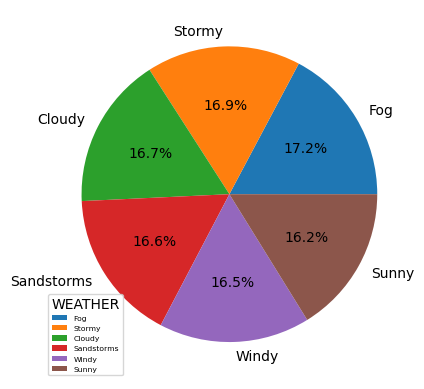

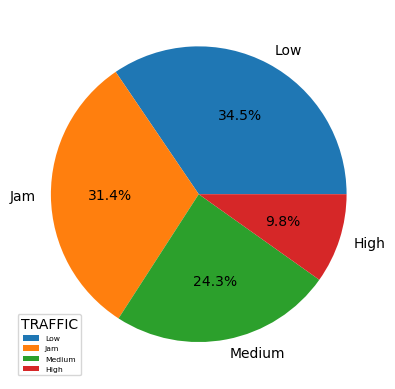

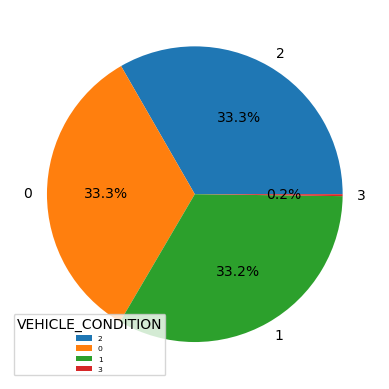

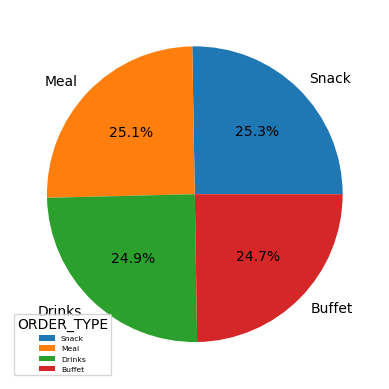

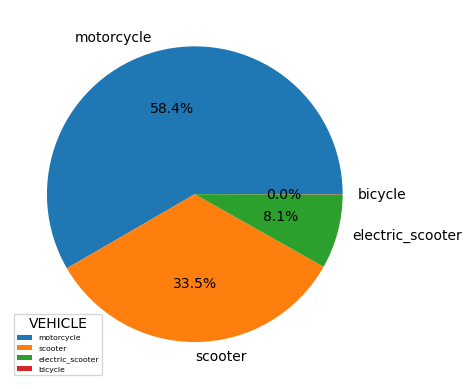

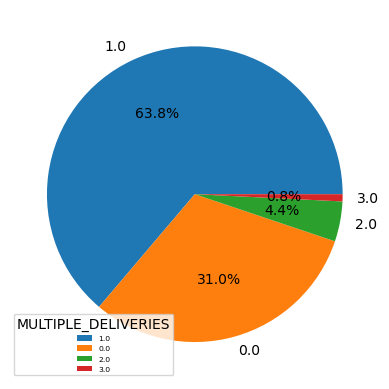

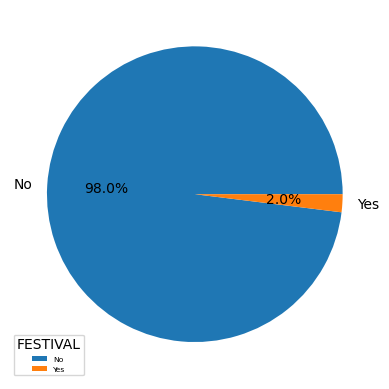

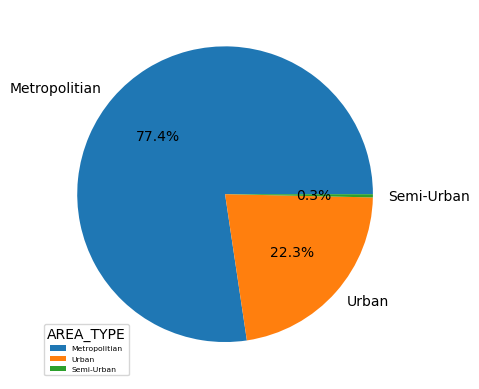

In [98]:
# Plot again the pie chart with categorical variables to see how NA'are replaced with mode
zomato_cat1 = zomato_data[['weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle',
       'multiple_deliveries', 'festival', 'area_type']]
pie_chart(zomato_cat1)

##### The mode value of the area_type: Metropolitan (74.8%) is used to impute NA's (2.6%), which changed the percentage of Metropolitan to 77.4%
- NA (2.6%) -> mode: Metropolitan (2.6%)

##### How many NA's are left 

In [100]:
print_na(zomato_data)

time_ordered contains 4141 NA's: True 9.48 %
time_picked contains 4776 NA's: True 10.94 %


In [102]:
len(zomato_data[zomato_data[["time_ordered","time_picked"]].isnull().any(axis = 1)])

8482

In [56]:
zomato_data

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,time_picked,weather,traffic,vehicle_condition,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,1900-01-01 21:55:00,1900-01-01 22:10:00,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,1900-01-01 14:55:00,1900-01-01 15:05:00,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,1900-01-01 17:30:00,1900-01-01 17:40:00,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,1900-01-01 09:20:00,1900-01-01 09:30:00,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,1900-01-01 19:50:00,1900-01-01 20:05:00,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45579,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,1900-01-01 11:35:00,1900-01-01 11:45:00,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32
45580,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,1900-01-01 19:55:00,1900-01-01 20:10:00,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36
45581,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,1900-01-01 23:50:00,NaT,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,1900-01-01 13:35:00,1900-01-01 13:40:00,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26


In [58]:
round(100 - len(zomato_data)/45584 *100,2)

4.19

#### There are 8482 missing values in time_ordered and time-picked, either one or both missing, 
#### So far, the percentage of the total data loss due to the deletion of missing values in rider age and ratings is 4.19%

#### Decision on missingness in time_ordered and time_picked
- We will delete the missing values that are present in both time_ordered and time_picked only since missing both times does not guarantee the reliability of the delivery time (target value)recorded
- We will keep the missing values that are present in either time_ordered and time_picked because one of the times recorded may be the indication of actual orders have placed or picked 

In [104]:
# Delete rows with missing rider age and rider ratings
zomato_data.dropna(subset=["time_ordered","time_picked"], how='all', inplace=True)

In [106]:
len(zomato_data[zomato_data[["time_ordered","time_picked"]].isnull().any(axis = 1)])

8047

In [250]:
round(100 - len(zomato_data)/45584 *100,2)

5.14

#### 1.6 Create new derived variable: time_to_pick using time_ordered and time_picked variables 
#### 배차시간 파생 변수 생성 

In [119]:
zomato_data[[ "time_ordered", "time_picked"]].head()

,time_ordered,time_picked
0,1900-01-01 21:55:00,1900-01-01 22:10:00
1,1900-01-01 14:55:00,1900-01-01 15:05:00
2,1900-01-01 17:30:00,1900-01-01 17:40:00
3,1900-01-01 09:20:00,1900-01-01 09:30:00
4,1900-01-01 19:50:00,1900-01-01 20:05:00


In [108]:
time_to_pick = zomato_data["time_picked"] - zomato_data["time_ordered"]
time_to_pick = time_to_pick.astype('timedelta64[s]').astype("int64")
time_to_pick = (time_to_pick/60).astype("int64")
zomato_data["time_to_pick"] = time_to_pick 
# Extract minutes into a new column
#df['minute'] = df['timestamp_col'].dt.minute
#print(df)

zomato_data["time_to_pick"].value_counts()

time_to_pick
 5                     11938
 10                    11693
 15                    11563
-153722867280912928     8047
Name: count, dtype: int64

#### There are 8047 missing values in time_ordered or time-picked 
#### So far, the percentage of the total data loss due to the deletion of missing values in rider age and ratings is 5.14%

#### And the new dataset with 43241 rows is ready to use for the analysis 

In [111]:
zomato_data

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,weather,traffic,vehicle_condition,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,1900-01-01 21:55:00,...,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,15
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,1900-01-01 14:55:00,...,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,10
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,1900-01-01 17:30:00,...,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,10
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,1900-01-01 09:20:00,...,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,10
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,1900-01-01 19:50:00,...,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45579,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,1900-01-01 11:35:00,...,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32,10
45580,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,1900-01-01 19:55:00,...,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36,15
45581,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,1900-01-01 23:50:00,...,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16,-153722867280912928
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,1900-01-01 13:35:00,...,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26,5


In [113]:
zomato_data.dtypes

order_id                               object
rider_id                               object
rider_age                             float64
rider_ratings                         float64
restaurant_latitude                   float64
restaurant_longitude                  float64
delivery_location_latitude            float64
delivery_location_longitude           float64
order_date                     datetime64[ns]
time_ordered                   datetime64[ns]
time_picked                    datetime64[ns]
weather                                object
traffic                                object
vehicle_condition                       int64
order_type                             object
vehicle                                object
multiple_deliveries                   float64
festival                               object
area_type                              object
delivery_min                            int64
time_to_pick                            int64
dtype: object

#### Summary of Data Description and Wrangling
- The Zomato dataset originally had 45584 rows with 20 variables.
- The number of missing values is high, which accounts for more than 25% of the dataset.
- In order to handle the missingness in the dataset, we inspect the missingness for each variable using pie charts \
  for categorical variables and distribution plots of the target variable conditional on numerical variables.
- After the inspection of each variable:
    - The missing values in the riders' age and ratings are removed since their missingnesses are relatively smaller (< 5%) \
compared to the whole dataset, and are concluded to be "Missing Completely at Random" based on the distribution plots 
    - The missing values in categorical variables are imputed using their modes to avoid large data loss
    - The missing values in the order times and pick-up times are removed if they are both missing; Missing values in one of the order times or pick-up times are not removed to keep the delivery time data for analysis (to avoid data loss). Missingness in one of the Order_time and pick-up time variables will be handled if need later for a complete case analysis. 

In [116]:
#### 1.6 Save the new dataset for further data analysis 
zomato_data.to_csv("C:/Users/minjk/Downloads/zomato_data.csv" , index = False, encoding = 'utf-8')

In [101]:
import sys
sys.path.append("C:\\Users\\minjk\\appdata\\local\\packages\\pythonsoftwarefoundation.python.3.13_qbz5n2kfra8p0\\localcache\\local-packages\\python313\\site-packages")